# data preprocessing:

In [1]:
import zipfile
import os

# Extract the zip file
with zipfile.ZipFile('isolated_words_per_user.zip', 'r') as zip_ref:
    zip_ref.extractall("isolated_words_per_user")

FileNotFoundError: [Errno 2] No such file or directory: 'isolated_words_per_user.zip'

In [ ]:
import pandas as pd
#import cv2
from PIL import Image
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
Image.LOAD_TRUNCATED_IMAGES = True


main_list = []

main_folder = "/content/isolated_words_per_user/isolated_words_per_user"

counter = 0;

# Iterate through each subfolder
for subfolder_name in os.listdir(main_folder):
    subfolder_path = os.path.join(main_folder, subfolder_name)

    # Check if it is a directory
    if os.path.isdir(subfolder_path):
        counter += 1

        # Iterate through files in the subfolder
        for file_name in os.listdir(subfolder_path):
            file_path = os.path.join(subfolder_path, file_name)

            #only take images of the word abjadiyah
            tokens = file_name.split("_")
            if(tokens[1] != 'abjadiyah'):
              continue

            temp_dic = {'user': tokens[0],
                        'class': tokens[1],
                        'img': Image.open(file_path) }

            main_list.append(temp_dic)

print(main_list[0:3])

[{'user': 'user073', 'class': 'abjadiyah', 'img': <PIL.PngImagePlugin.PngImageFile image mode=L size=374x128 at 0x7F620D1C9B50>}, {'user': 'user073', 'class': 'abjadiyah', 'img': <PIL.PngImagePlugin.PngImageFile image mode=L size=208x128 at 0x7F620D1C9250>}, {'user': 'user073', 'class': 'abjadiyah', 'img': <PIL.PngImagePlugin.PngImageFile image mode=L size=221x128 at 0x7F620D175BD0>}]


In [ ]:
df = pd.DataFrame.from_records(main_list)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   user    810 non-null    object
 1   class   810 non-null    object
 2   img     810 non-null    object
dtypes: object(3)
memory usage: 19.1+ KB
None


In [ ]:
print(df.head())

      user      class                                                img
0  user073  abjadiyah  <PIL.PngImagePlugin.PngImageFile image mode=L ...
1  user073  abjadiyah  <PIL.PngImagePlugin.PngImageFile image mode=L ...
2  user073  abjadiyah  <PIL.PngImagePlugin.PngImageFile image mode=L ...
3  user073  abjadiyah  <PIL.PngImagePlugin.PngImageFile image mode=L ...
4  user073  abjadiyah  <PIL.PngImagePlugin.PngImageFile image mode=L ...


In [ ]:
print(df['img'][93].width)
print(df['img'][93].height)

241
128


In [ ]:
df['user'] = df['user'].str.extract('(\d+)').astype(int)

In [ ]:
df['user'] = df['user'].astype('int64')

In [ ]:
print(df['user'].head())

0    73
1    73
2    73
3    73
4    73
Name: user, dtype: int64


In [ ]:
print(df['user'].max())
print(df['user'].min())

81
0


In [ ]:
df['user'] = df['user'] - 1

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   user    810 non-null    int64 
 1   class   810 non-null    object
 2   img     810 non-null    object
dtypes: int64(1), object(2)
memory usage: 19.1+ KB


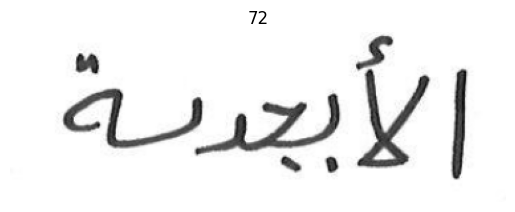

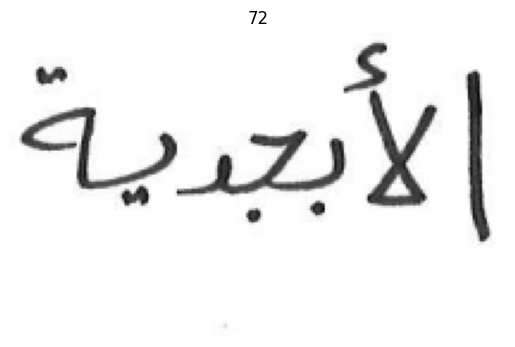

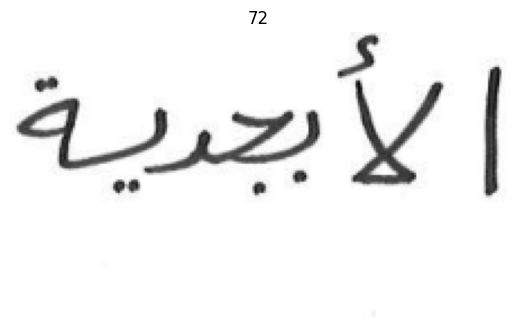

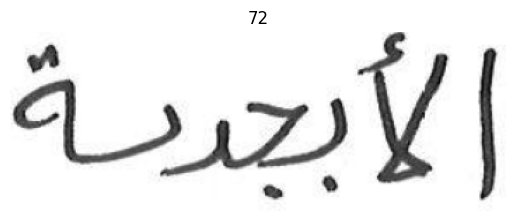

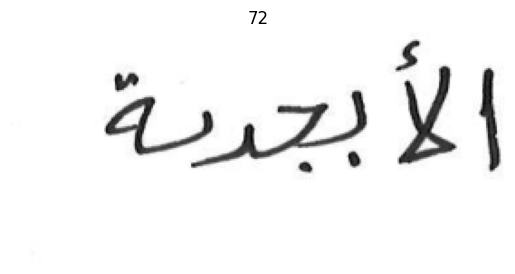

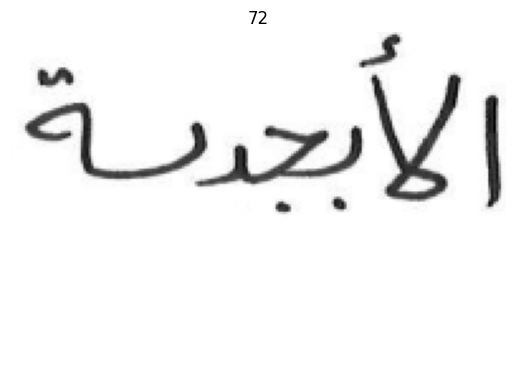

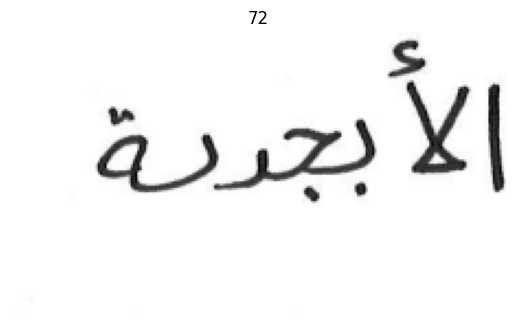

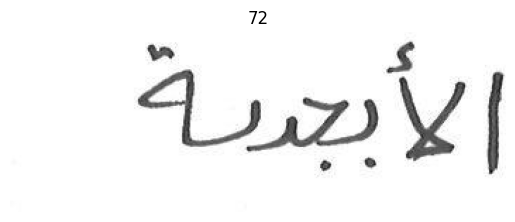

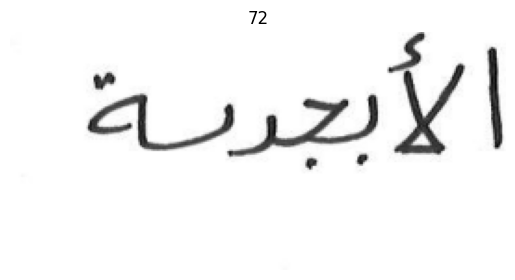

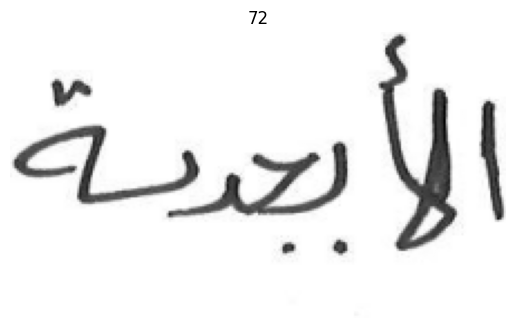

In [ ]:
import matplotlib.pyplot as plt

counter = 0

for index, row in df.iterrows():
    plt.imshow(row['img'], cmap='gray')
    plt.title(row['user'])
    plt.axis('off')
    plt.show()
    # img = row['img']
    # img.show()

    counter += 1
    if(counter >= 10):
      break

# prepare the data loaders:

In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from sklearn.preprocessing import LabelEncoder

class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        # self.label_encoder = label_encoder

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        label = self.dataframe.iloc[idx]['user']
        image = self.dataframe.iloc[idx]['img']

        label = torch.tensor(label, dtype=torch.long)

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
from torch.utils.data import DataLoader


train_dataset = ImageDataset(train_df, transform=transform)
test_dataset = ImageDataset(test_df, transform=transform)

batch_size = 20
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# CNN models:

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 128x128x1
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)  # Output: 124x124x6
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 62x62x6
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)  # Output: 58x58x16
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 29x29x16

        # Flattened size: 29 * 29 * 16 = 13456
        self.fc1 = nn.Linear(29 * 29 * 16, 1200)
        self.fc2 = nn.Linear(1200, 256)
        self.fc3 = nn.Linear(256, 82)  # 82 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Move the model to the appropriate device (e.g., GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = NetCNN().to(device)

In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.1)

In [ ]:
import matplotlib.pyplot as plt

# Initialize lists to store loss and accuracy
epoch_losses = []
epoch_accuracies = []

for epoch in range(20):
    net.train()
    running_loss = 0.0
    i = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        i += 1
        if i % 20 == 19:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

    # Calculate and store epoch loss and accuracy
    epoch_loss = running_loss / len(train_loader)
    epoch_losses.append(epoch_loss)

    epoch_accuracy = 100.0 * correct / total
    epoch_accuracies.append(epoch_accuracy)

    print(f'Epoch {epoch + 1} completed. Loss: {epoch_loss:.3f}, Accuracy: {epoch_accuracy:.2f}%')

print('Finished Training')

# Plot Loss vs. Epoch
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, 21), epoch_losses, marker='o', label='Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy vs. Epoch
plt.subplot(1, 2, 2)
plt.plot(range(1, 21), epoch_accuracies, marker='o', label='Accuracy', color='orange')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


[1,    20] loss: 0.259
[2,    20] loss: 0.577
[3,    20] loss: 0.080
[4,    20] loss: 0.076
[5,    20] loss: 0.004
[6,    20] loss: 0.001
[7,    20] loss: 0.000
[8,    20] loss: 0.000
[9,    20] loss: 0.000
[10,    20] loss: 0.000
Finished Training


In [ ]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
  for data in test_loader:
    images, labels = data
    images, labels = images.to(device), labels.to(device)
    # calculate outputs by running images through the network
    outputs = net(images)
    # the class with the highest energy is what we choose as prediction
    _, predicted = torch.max(outputs.data, 1)
    print(f"predicted: {predicted}")
    print(f"labels: {labels}")

    print("***************************")
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
print(f"correctly predicted: {correct}")
print(f"total: {total}")
print(f'Accuracy of the network on the 10000 test images: {100 * correct// total} %')

predicted: tensor([34, 74, 81, 20, 62, 26, 19, 61,  8, 37, 67,  5, 70, 13, 66, 20, 10, 44,
        59, 19], device='cuda:0')
labels: tensor([ 2,  9, 81,  4,  5, 54, 19, 61,  8, 37, 46, 40, 70, 53, 77, 32,  8, 74,
         1,  5], device='cuda:0')
***************************
predicted: tensor([81, 41, 11, 64, 23, 63, 63, 68, 52, 25, 31,  9, 31, 49, 76, 10, 70, 76,
        34, 19], device='cuda:0')
labels: tensor([21, 46, 11, 11, 33, 33, 63, 68, 68,  0,  7, 35,  9, 63, 41, 10, 11, 48,
        46, 19], device='cuda:0')
***************************
predicted: tensor([13,  4,  4, 39, 36, 65, 67, 23, 54, 55, 75, 31, 61, 68, 45, 39, 33, 26,
         5, 54], device='cuda:0')
labels: tensor([46, 38,  4, 21, 36, 30,  5, 26, 51, 29, 75, 36, 61,  9, 17, 20, 51, 80,
        55, 29], device='cuda:0')
***************************
predicted: tensor([81, 77, 54, 60, 39, 16,  3, 37,  7, 12, 78, 79,  9, 38, 25, 64, 61, 50,
        34,  1], device='cuda:0')
labels: tensor([15,  6, 39, 66, 47, 18, 28, 13, 42

# task 2: data augmentation:

In [ ]:
from PIL import Image
import random

percentages = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# Crop some images:
def crop_image(image):
    if not isinstance(image, Image.Image):
        raise ValueError("Input must be a Pillow Image object.")

    width, height = image.size

    random_percent = random.choice(percentages)

    start_height = int(height * random_percent)
    end_height = int(height * (1 - random_percent))

    start_width = int(width * random_percent)
    end_width = int(width * (1 - random_percent))

    cropped_img = image.crop((start_width, start_height, end_width, end_height))
    return cropped_img


(432, 128)


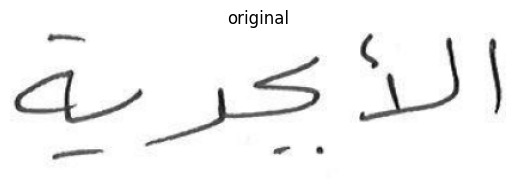

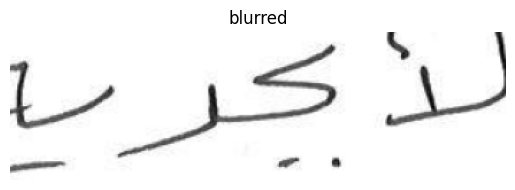

In [ ]:
img = df['img'][20]
# img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

print(img.size)
plt.imshow(img, cmap='gray')
plt.title("original")
plt.axis('off')
plt.show()

cropped = crop_image(img)
plt.imshow(cropped, cmap='gray')
plt.title("blurred")
plt.axis('off')
plt.show()

In [ ]:
sampled_df = df.sample(frac=0.3, random_state=42)
new_rows = []

for i, row in sampled_df.iterrows():
    user, label, img = row['user'], row['class'], row['img']
    cropped_img = crop_image(img)

    new_rows.append({'user': user, 'class': label, 'img': cropped_img})

augmented_df = pd.DataFrame(new_rows)
final_df = pd.concat([df, augmented_df], ignore_index=True)

print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   user    1053 non-null   int64 
 1   class   1053 non-null   object
 2   img     1053 non-null   object
dtypes: int64(1), object(2)
memory usage: 24.8+ KB
None


In [ ]:
from PIL import Image
import numpy as np

# Add Gaussian noise
def add_gaussian_noise(image, var, mean=20):
    if not isinstance(image, Image.Image):
        raise ValueError("Input must be a Pillow Image object.")

    image_array = np.array(image, dtype=np.float32)

    sigma = var**0.5
    gaussian_noise = np.random.normal(mean, sigma, image_array.shape)

    noisy_image_array = image_array + gaussian_noise

    # Clip values to ensure they stay in valid range
    noisy_image_array = np.clip(noisy_image_array, 0, 255).astype(np.uint8)

    noisy_image = Image.fromarray(noisy_image_array)

    return noisy_image


(432, 128)


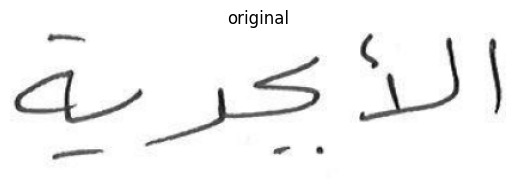

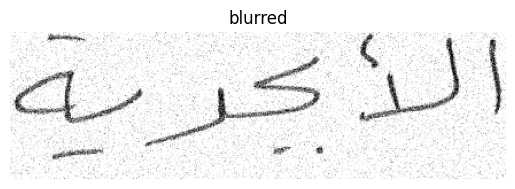

In [ ]:
img = df['img'][20]
# img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

print(img.size)
plt.imshow(img, cmap='gray')
plt.title("original")
plt.axis('off')
plt.show()

blurred = add_gaussian_noise(img, var=1500, mean=20)
plt.imshow(blurred, cmap='gray')
plt.title("blurred")
plt.axis('off')
plt.show()

In [ ]:
sampled_df = df.sample(frac=0.3, random_state=42)
new_rows = []

for i, row in sampled_df.iterrows():
    user, label, img = row['user'], row['class'], row['img']
    blurred = add_gaussian_noise(img, var=1500, mean=20)

    new_rows.append({'user': user, 'class': label, 'img': cropped_img})

augmented_df = pd.DataFrame(new_rows)
final_df = pd.concat([final_df, augmented_df], ignore_index=True)

print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   user    1296 non-null   int64 
 1   class   1296 non-null   object
 2   img     1296 non-null   object
dtypes: int64(1), object(2)
memory usage: 30.5+ KB
None


In [ ]:
from PIL import Image
import random

# Rotate image by a random angle
def rotate_image(image):
    if not isinstance(image, Image.Image):
        raise ValueError("Input must be a Pillow Image object.")

    degree = random.randint(-30, 30)

    rotated_image = image.rotate(degree, resample=Image.BICUBIC, expand=True)

    return rotated_image

(299, 128)


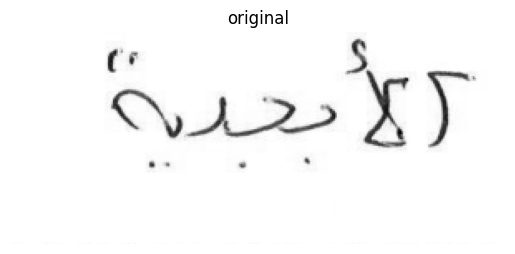

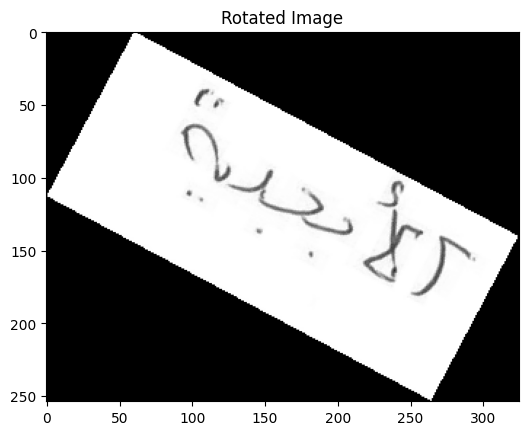

In [ ]:
img = df['img'][130]

print(img.size)
plt.imshow(img, cmap='gray')
plt.title("original")
plt.axis('off')
plt.show()

rotated = rotate_image(img)
plt.imshow(rotated, cmap='gray')
plt.title('Rotated Image')
plt.show()

In [ ]:
sampled_df = df.sample(frac=0.4, random_state=42)
new_rows = []

for i, row in sampled_df.iterrows():
    user, label, img = row['user'], row['class'], row['img']
    blurred = rotate_image(img)

    new_rows.append({'user': user, 'class': label, 'img': cropped_img})

augmented_df = pd.DataFrame(new_rows)
final_df = pd.concat([final_df, augmented_df], ignore_index=True)

print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   user    1620 non-null   int64 
 1   class   1620 non-null   object
 2   img     1620 non-null   object
dtypes: int64(1), object(2)
memory usage: 38.1+ KB
None


In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(final_df, test_size=0.2, random_state=42)

train_dataset_aug = ImageDataset(train_df, transform=transform)
test_dataset_aug = ImageDataset(test_df, transform=transform)

batch_size = 20
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class NetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 128x128x1
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)  # Output: 124x124x6
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 62x62x6
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)  # Output: 58x58x16
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # Output: 29x29x16

        # Flattened size: 29 * 29 * 16 = 13456
        self.fc1 = nn.Linear(29 * 29 * 16, 1200)
        self.fc2 = nn.Linear(1200, 256)
        self.fc3 = nn.Linear(256, 82)  # 82 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # Flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Move the model to the appropriate device (e.g., GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = NetCNN().to(device)

In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.08)

[1,    40] loss: 1.719
Epoch 1 completed. Loss: 1.762, Accuracy: 1.31%
[2,    40] loss: 1.712
Epoch 2 completed. Loss: 1.756, Accuracy: 1.77%
[3,    40] loss: 1.698
Epoch 3 completed. Loss: 1.751, Accuracy: 2.01%
[4,    40] loss: 1.688
Epoch 4 completed. Loss: 1.734, Accuracy: 2.24%
[5,    40] loss: 1.675
Epoch 5 completed. Loss: 1.730, Accuracy: 1.85%
[6,    40] loss: 1.666
Epoch 6 completed. Loss: 1.723, Accuracy: 2.16%
[7,    40] loss: 1.654
Epoch 7 completed. Loss: 1.709, Accuracy: 2.70%
[8,    40] loss: 1.640
Epoch 8 completed. Loss: 1.698, Accuracy: 3.01%
[9,    40] loss: 1.613
Epoch 9 completed. Loss: 1.689, Accuracy: 3.63%
[10,    40] loss: 1.591
Epoch 10 completed. Loss: 1.642, Accuracy: 4.71%
[11,    40] loss: 1.568
Epoch 11 completed. Loss: 1.595, Accuracy: 6.10%
[12,    40] loss: 1.502
Epoch 12 completed. Loss: 1.522, Accuracy: 7.95%
[13,    40] loss: 1.369
Epoch 13 completed. Loss: 1.431, Accuracy: 14.35%
[14,    40] loss: 1.202
Epoch 14 completed. Loss: 1.273, Accuracy: 2

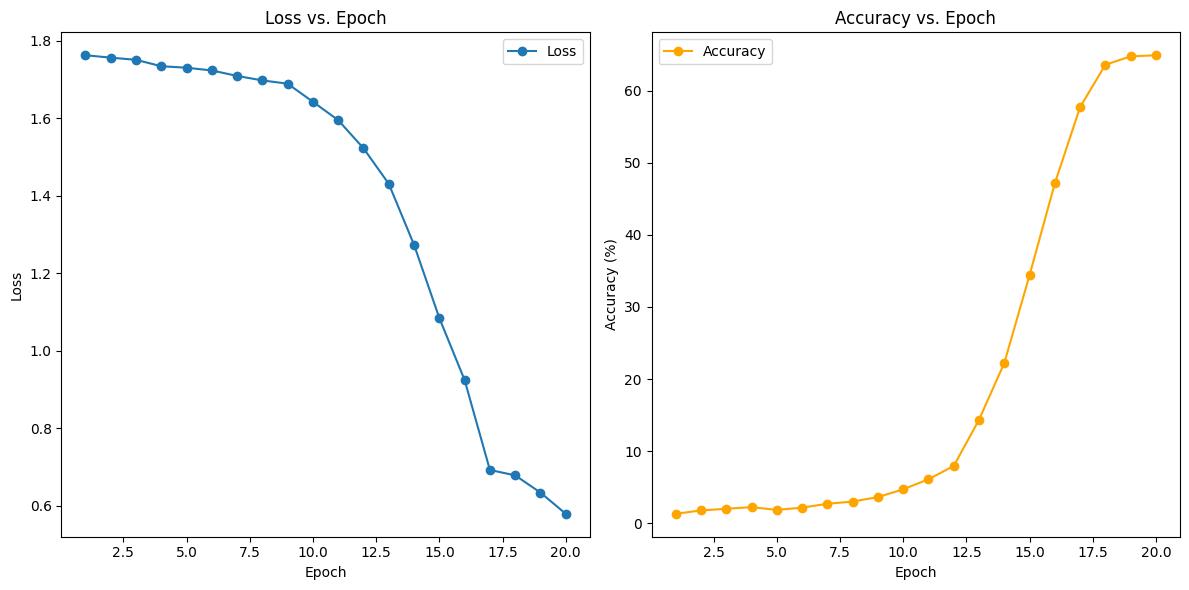

In [ ]:
import matplotlib.pyplot as plt

# Initialize lists to store loss and accuracy
epoch_losses = []
epoch_accuracies = []

for epoch in range(20):
    net.train()
    running_loss = 0.0
    i = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        i += 1
        if i % 40 == 39:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

    # Calculate and store epoch loss and accuracy
    epoch_loss = running_loss / len(train_loader)
    epoch_losses.append(epoch_loss)

    epoch_accuracy = 100.0 * correct / total
    epoch_accuracies.append(epoch_accuracy)

    print(f'Epoch {epoch + 1} completed. Loss: {epoch_loss:.3f}, Accuracy: {epoch_accuracy:.2f}%')

print('Finished Training')

# Plot Loss vs. Epoch
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, 21), epoch_losses, marker='o', label='Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy vs. Epoch
plt.subplot(1, 2, 2)
plt.plot(range(1, 21), epoch_accuracies, marker='o', label='Accuracy', color='orange')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
  for data in test_loader:
    images, labels = data
    images, labels = images.to(device), labels.to(device)
    # calculate outputs by running images through the network
    outputs = net(images)
    # the class with the highest energy is what we choose as prediction
    _, predicted = torch.max(outputs.data, 1)
    print(f"predicted: {predicted}")
    print(f"labels: {labels}")

    print("***************************")
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
print(f"correctly predicted: {correct}")
print(f"total: {total}")
print(f'Accuracy of the network on the 10000 test images: {100 * correct// total} %')

predicted: tensor([42, 73, 70,  3, 70, 70, 70, 17, 65, 73, 65, 70, 12, 33, 73, 71, 35, 18,
         8, 28], device='cuda:0')
labels: tensor([21, 73, 53, 37, 44, 30,  2,  9, 65, 31, 79, 41,  9, 10, 76, 71, 60, 59,
         8, 28], device='cuda:0')
***************************
predicted: tensor([61,  2, 73, 32, 70,  1, 70, 78, 24, 70, 54, 17, 13, 22, 34, 45, 70, 70,
         4, 52], device='cuda:0')
labels: tensor([17,  2,  2, 32,  0,  1, 43, 55,  0, 56, 54, 17, 47, 76, 33, 39,  6,  3,
         4, 22], device='cuda:0')
***************************
predicted: tensor([14,  4, 74, 54, 70, 70, 71, 70, 10, 52, 51, 70, 69, 77, 70, 49, 46, 40,
        70, 70], device='cuda:0')
labels: tensor([14, 64, 63, 55, 69, 32, 71, 45, 10, 31, 33, 46, 20,  4, 38, 25, 46, 55,
         5, 22], device='cuda:0')
***************************
predicted: tensor([64, 17, 44, 70, 53, 42, 49, 30, 73, 70, 46, 70, 61, 54, 70, 70, 69, 30,
        79, 70], device='cuda:0')
labels: tensor([67, 66, 44, 71, 26,  9, 49, 53,  3

# task 4: pretrained CNN model

## ResNet-18:

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [ ]:
import torch.nn as nn
from torchvision import models

net = models.resnet18(weights='IMAGENET1K_V1')

# Modify the fully connected (fc) layer for 10 classes
num_features = net.fc.in_features
net.fc = nn.Linear(num_features, 82)

net = net.to(device)

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

transform2 = transforms.Compose(
            [transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

In [ ]:
from torch.utils.data import DataLoader


train_dataset = ImageDataset(train_df, transform=transform2)
test_dataset = ImageDataset(test_df, transform=transform2)

batch_size = 20
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

[1,    40] loss: 1.762
Epoch 1 completed. Loss: 1.772, Accuracy: 1.62%
[2,    40] loss: 1.627
Epoch 2 completed. Loss: 1.641, Accuracy: 8.49%
[3,    40] loss: 1.463
Epoch 3 completed. Loss: 1.458, Accuracy: 21.22%
[4,    40] loss: 1.277
Epoch 4 completed. Loss: 1.283, Accuracy: 36.96%
[5,    40] loss: 1.103
Epoch 5 completed. Loss: 1.149, Accuracy: 46.68%
[6,    40] loss: 0.978
Epoch 6 completed. Loss: 1.021, Accuracy: 53.78%
[7,    40] loss: 0.875
Epoch 7 completed. Loss: 0.918, Accuracy: 59.65%
[8,    40] loss: 0.802
Epoch 8 completed. Loss: 0.841, Accuracy: 62.35%
[9,    40] loss: 0.764
Epoch 9 completed. Loss: 0.775, Accuracy: 62.65%
[10,    40] loss: 0.700
Epoch 10 completed. Loss: 0.762, Accuracy: 63.43%
[11,    40] loss: 0.680
Epoch 11 completed. Loss: 0.744, Accuracy: 63.89%
[12,    40] loss: 0.692
Epoch 12 completed. Loss: 0.664, Accuracy: 64.12%
[13,    40] loss: 0.664
Epoch 13 completed. Loss: 0.668, Accuracy: 64.51%
[14,    40] loss: 0.666
Epoch 14 completed. Loss: 0.640, A

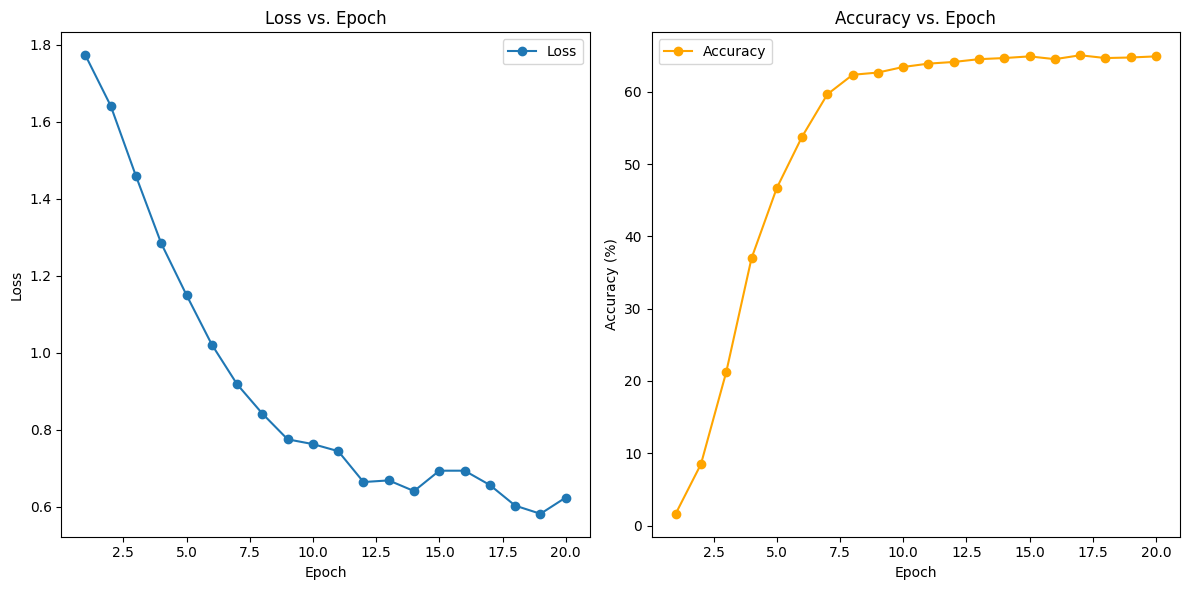

In [ ]:
import matplotlib.pyplot as plt

# Initialize lists to store loss and accuracy
epoch_losses = []
epoch_accuracies = []

for epoch in range(20):
    net.train()
    running_loss = 0.0
    i = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        i += 1
        if i % 40 == 39:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

    # Calculate and store epoch loss and accuracy
    epoch_loss = running_loss / len(train_loader)
    epoch_losses.append(epoch_loss)

    epoch_accuracy = 100.0 * correct / total
    epoch_accuracies.append(epoch_accuracy)

    print(f'Epoch {epoch + 1} completed. Loss: {epoch_loss:.3f}, Accuracy: {epoch_accuracy:.2f}%')

print('Finished Training')

# Plot Loss vs. Epoch
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, 21), epoch_losses, marker='o', label='Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy vs. Epoch
plt.subplot(1, 2, 2)
plt.plot(range(1, 21), epoch_accuracies, marker='o', label='Accuracy', color='orange')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
  for data in test_loader:
    images, labels = data
    images, labels = images.to(device), labels.to(device)
    # calculate outputs by running images through the network
    outputs = net(images)
    # the class with the highest energy is what we choose as prediction
    _, predicted = torch.max(outputs.data, 1)
    print(f"predicted: {predicted}")
    print(f"labels: {labels}")

    print("***************************")
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
print(f"correctly predicted: {correct}")
print(f"total: {total}")
print(f'Accuracy of the network on the 10000 test images: {100 * correct// total} %')

predicted: tensor([21,  2, 70, 37, 70, 70, 70, 80, 65, 31, 79, 61, 17, 10, 76, 71, 45, 17,
         8, 28], device='cuda:0')
labels: tensor([21, 73, 53, 37, 44, 30,  2,  9, 65, 31, 79, 41,  9, 10, 76, 71, 60, 59,
         8, 28], device='cuda:0')
***************************
predicted: tensor([29,  2,  2, 32, 70,  1, 70, 55,  0, 70, 54, 17, 47, 76, 33, 74, 70, 70,
         4, 21], device='cuda:0')
labels: tensor([17,  2,  2, 32,  0,  1, 43, 55,  0, 56, 54, 17, 47, 76, 33, 39,  6,  3,
         4, 22], device='cuda:0')
***************************
predicted: tensor([14, 64, 63,  5, 70, 70, 62, 70, 10, 69, 33, 70, 20,  4, 70, 25, 46, 19,
        70, 70], device='cuda:0')
labels: tensor([14, 64, 63, 55, 69, 32, 71, 45, 10, 31, 33, 46, 20,  4, 38, 25, 46, 55,
         5, 22], device='cuda:0')
***************************
predicted: tensor([67,  6, 44, 70, 26, 44, 49, 53, 43, 70, 46, 70, 65,  7, 70, 70, 32, 30,
        79, 70], device='cuda:0')
labels: tensor([67, 66, 44, 71, 26,  9, 49, 53,  3

## ResNet-50

In [ ]:
import torch.nn as nn
from torchvision import models

net = models.resnet50(weights='IMAGENET1K_V1')

# Modify the fully connected (fc) layer for 10 classes
num_features = net.fc.in_features
net.fc = nn.Linear(num_features, 82)

net = net.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 142MB/s]


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

transform2 = transforms.Compose(
            [transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.Grayscale(num_output_channels=3),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

In [ ]:
from torch.utils.data import DataLoader

train_dataset = ImageDataset(train_df, transform=transform2)
test_dataset = ImageDataset(test_df, transform=transform2)

batch_size = 20
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [ ]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

[1,    40] loss: 1.727
Epoch 1 completed. Loss: 1.770, Accuracy: 1.47%
[2,    40] loss: 1.650
Epoch 2 completed. Loss: 1.675, Accuracy: 6.56%
[3,    40] loss: 1.522
Epoch 3 completed. Loss: 1.509, Accuracy: 17.44%
[4,    40] loss: 1.364
Epoch 4 completed. Loss: 1.348, Accuracy: 27.39%
[5,    40] loss: 1.208
Epoch 5 completed. Loss: 1.185, Accuracy: 40.59%
[6,    40] loss: 1.064
Epoch 6 completed. Loss: 1.034, Accuracy: 51.54%
[7,    40] loss: 0.942
Epoch 7 completed. Loss: 0.918, Accuracy: 55.86%
[8,    40] loss: 0.814
Epoch 8 completed. Loss: 0.860, Accuracy: 61.27%
[9,    40] loss: 0.774
Epoch 9 completed. Loss: 0.729, Accuracy: 63.12%
[10,    40] loss: 0.729
Epoch 10 completed. Loss: 0.701, Accuracy: 64.51%
[11,    40] loss: 0.694
Epoch 11 completed. Loss: 0.675, Accuracy: 64.89%
[12,    40] loss: 0.649
Epoch 12 completed. Loss: 0.686, Accuracy: 64.27%
[13,    40] loss: 0.642
Epoch 13 completed. Loss: 0.679, Accuracy: 64.97%
[14,    40] loss: 0.647
Epoch 14 completed. Loss: 0.645, A

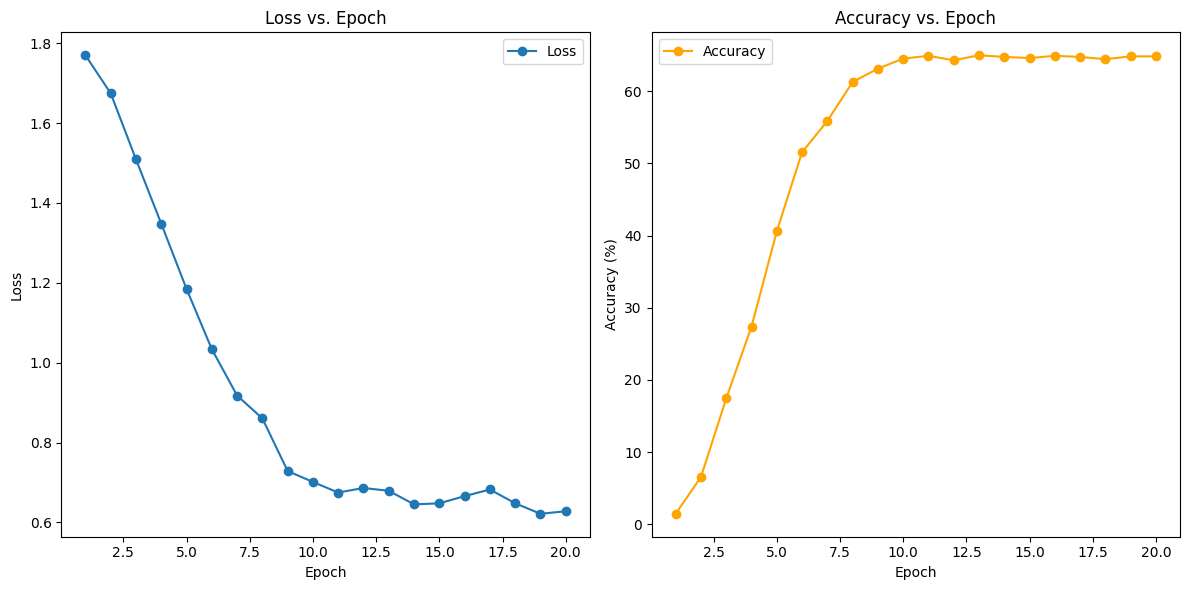

In [ ]:
import matplotlib.pyplot as plt

# Initialize lists to store loss and accuracy
epoch_losses = []
epoch_accuracies = []

for epoch in range(20):
    net.train()
    running_loss = 0.0
    i = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        i += 1
        if i % 40 == 39:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

    # Calculate and store epoch loss and accuracy
    epoch_loss = running_loss / len(train_loader)
    epoch_losses.append(epoch_loss)

    epoch_accuracy = 100.0 * correct / total
    epoch_accuracies.append(epoch_accuracy)

    print(f'Epoch {epoch + 1} completed. Loss: {epoch_loss:.3f}, Accuracy: {epoch_accuracy:.2f}%')

print('Finished Training')

# Plot Loss vs. Epoch
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, 21), epoch_losses, marker='o', label='Loss')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy vs. Epoch
plt.subplot(1, 2, 2)
plt.plot(range(1, 21), epoch_accuracies, marker='o', label='Accuracy', color='orange')
plt.title('Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
  for data in test_loader:
    images, labels = data
    images, labels = images.to(device), labels.to(device)
    # calculate outputs by running images through the network
    outputs = net(images)
    # the class with the highest energy is what we choose as prediction
    _, predicted = torch.max(outputs.data, 1)
    print(f"predicted: {predicted}")
    print(f"labels: {labels}")

    print("***************************")
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
print(f"correctly predicted: {correct}")
print(f"total: {total}")
print(f'Accuracy of the network on the 10000 test images: {100 * correct// total} %')

predicted: tensor([21,  2, 70, 37, 70, 70, 70, 17, 65, 31, 79, 51, 81, 70, 76, 71, 45, 17,
         8, 28], device='cuda:0')
labels: tensor([21, 73, 53, 37, 44, 30,  2,  9, 65, 31, 79, 41,  9, 10, 76, 71, 60, 59,
         8, 28], device='cuda:0')
***************************
predicted: tensor([35,  2,  2, 32, 70, 32, 70, 55, 46, 70, 54, 17, 36, 76, 24, 45, 70, 70,
         4, 22], device='cuda:0')
labels: tensor([17,  2,  2, 32,  0,  1, 43, 55,  0, 56, 54, 17, 47, 76, 33, 39,  6,  3,
         4, 22], device='cuda:0')
***************************
predicted: tensor([36, 64, 36, 55, 70, 70, 71, 70, 10, 31, 33, 70, 20,  4, 70, 25, 46, 19,
        70, 70], device='cuda:0')
labels: tensor([14, 64, 63, 55, 69, 32, 71, 45, 10, 31, 33, 46, 20,  4, 38, 25, 46, 55,
         5, 22], device='cuda:0')
***************************
predicted: tensor([67, 66, 44, 70, 26,  2, 49, 53, 14, 70, 46, 70, 65, 55, 70, 70, 32, 30,
        79, 70], device='cuda:0')
labels: tensor([67, 66, 44, 71, 26,  9, 49, 53,  3